---
downloads:
  - url: https://colab.research.google.com/github/Souvik-Mandal-Harvard/Computational-Behavioral-Sciences_LS100_Harvard/blob/main/LS100_02_Data-Science_Stats/LS100_DataScience_Classical-Statistical-Tests_LastUpdate-202606.ipynb
    title: Open in Colab
  - url: https://codespaces.new/Souvik-Mandal-Harvard/Computational-Behavioral-Sciences_LS100_Harvard?devcontainer_path=.devcontainer%2Fdevcontainer.json
    title: Open in GitHub Codespaces
  - file: LS100_DataScience_Classical-Statistical-Tests_LastUpdate-202606.ipynb
    title: Download notebook
---


# Choosing & Running Classical Statistical Tests in Python

*Authored by* **Souvik Mandal, Ph.D.**

*Project Leader & Instructor, Computational Behavioral Sciences, LS100, FAS, Harvard University* | Linkedin ID: [souvik-mandal-phd](https://www.linkedin.com/in/souvik-mandal-phd/)

---


You have collected data, cleaned it, visualized it, and computed summaries. Now comes the question every research study must answer: **is there any pattern, and if so, is the pattrn significant, or could it be just by chance?** Classical statistical tests are the tools that answer it.

This notebook is a hands-on guide to the common tests of behavioural research: **t-tests, ANOVA, correlation, regression, the chi-square test, and their non-parametric counterparts.** For each of these tests, you will learn *when* to use it, *what data structure it assumes*, *how to run it in Python, and how to interpret and report it honestly*. We use `scipy.stats` and `statsmodels`, the two standard statistics libraries.

A theme runs through the whole notebook: **a p-value is never the whole story.** We will always pair it with an **effect size** (how big is the difference?) and think about assumptions. By the end of this notebook, you will be able to look at a research question, pick the right test, run it, and state what it does and does not show — and you will understand why, when your data has repeated measures or nesting, you need the **mixed-effects models** of the next notebook.


_Last updated: 2026-07-02_ <!--last-updated-->


## How to Use This Notebook Well

* **Run every cell yourself**, top to bottom — all tests use the one dataset built in Section 0.
* For each test, read the **"When to use it"** box first and try to decide if it fits *before* seeing the code.
* Pay attention to the **interpretation** after each result. Running a test is one line; understanding it is the skill.
* **Mini Challenges** and **Checkpoints** are for you. The final **decision guide** (Section 7) is worth bookmarking.

> A word of caution up front: statistics is easy to run and easy to misuse. This notebook teaches the mechanics *and* the good habits — effect sizes, assumption checks, and honesty about multiple comparisons — that separate an genuine analysis from "p-hacking".

---


### Table of Content:

0. [Setup & Our Dataset](#sec0)
1. [The Logic of Hypothesis Testing](#sec1)
2. [Descriptive Statistics & Confidence Intervals](#sec2)
3. [Checking Assumptions](#sec3)
4. [Comparing Means](#sec4)
    - [4.1. One-Sample t-test](#s41)
    - [4.2. Independent Two-Sample t-test](#s42)
    - [4.3. Paired t-test](#s43)
    - [4.4. One-Way ANOVA (3+ groups) & Post-hoc](#s44)
5. [When Assumptions Fail: Non-Parametric Tests](#sec5)
6. [Measuring Relationships](#sec6)
    - [6.1. Correlation (Pearson & Spearman)](#s61)
    - [6.2. Simple Linear Regression](#s62)
    - [6.3. Chi-Square Test for Categorical Data](#s63)
7. [Choosing the Right Test (Decision Guide) & the Multiple-Comparisons Trap](#sec7)
8. [Bridge to Mixed-Effects Models + Weekly Challenge](#sec8)

---


<a id="sec0"></a>
## Section 0: Setup & Our Dataset

We import 
- `NumPy` and `pandas` for data handling, 
- **`scipy.stats`** (the test functions) and **`statsmodels`** (regression, ANOVA tables, post-hoc tests). 
- `matplotlib` /`seaborn` for creating plots — remember from Notebook 03 that it is always a good practice to *visualize* the data before conducting further analyses.


In [ ]:
# If you don't have scipy statsmodels installed, uncomment the following line to install it:
# !pip install scipy
# !pip install statsmodels

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf
import statsmodels.api as sm

print("scipy   :", __import__("scipy").__version__)
print("statsmodels:", sm.__version__)

scipy   : 1.16.3
statsmodels: 0.14.5


We simulate a tidy dataset from a fictional learning study. Sixty participants — half **novices**, half **experts** — each trained with one of three **methods** (massed, spaced, interleaved), logged their **practice hours**, and were scored on a task. We also recorded a **score for "balance" before and after** a short intervention (a *paired* measure), and whether each participant ultimately **passed**. A fixed random seed keeps the numbers reproducible.

In [4]:
rng = np.random.default_rng(7)
n = 60

group = np.repeat(["novice", "expert"], n // 2)          # 30 novices, 30 experts
method = rng.choice(["massed", "spaced", "interleaved"], size=n)
practice_hours = rng.uniform(0, 20, n)

# Score is built from real effects: experts score higher, methods differ,
# and more practice helps -- plus random noise. (This is the "ground truth"
# the tests below will try to recover.)
group_effect  = np.where(group == "expert", 10.0, 0.0)
method_effect = np.select([method == "massed", method == "spaced", method == "interleaved"],
                          [0.0, 4.0, 8.0])
score = (55 + group_effect + method_effect + 0.8 * practice_hours
         + rng.normal(0, 7, n)).clip(0, 100)

# Reaction time (seconds): experts are faster. Independent of score.
reaction_time = np.where(group == "expert",
                         rng.normal(0.62, 0.12, n),
                         rng.normal(0.78, 0.15, n))

# A paired measure: balance score before and after an intervention (improves ~4 points).
balance_pre = rng.normal(70, 9, n)
balance_post = balance_pre + rng.normal(4, 5, n)

# Categorical outcome for the chi-square test.
passed = np.where(score >= 75, "pass", "fail")

df = pd.DataFrame({
    "participant": np.arange(1, n + 1),
    "group": group, "method": method,
    "practice_hours": practice_hours.round(1),
    "score": score.round(1), "reaction_time": reaction_time.round(3),
    "balance_pre": balance_pre.round(1), "balance_post": balance_post.round(1),
    "passed": passed,
})
print("Shape:", df.shape)
df.head()


Shape: (60, 9)


,participant,group,method,practice_hours,score,reaction_time,balance_pre,balance_post,passed
0,1,novice,interleaved,9.9,75.5,0.628,68.8,82.8,pass
1,2,novice,spaced,5.0,62.8,0.778,69.9,72.6,fail
2,3,novice,interleaved,0.2,67.9,0.906,58.1,61.1,fail
3,4,novice,interleaved,3.8,63.7,0.533,85.5,84.3,fail
4,5,novice,spaced,13.8,77.4,0.464,83.1,88.7,pass


<a id="sec1"></a>
## Section 1: The Logic of Hypothesis Testing

Before any specific test, you need the shared logic they all run on. It is a kind of proof by contradiction.

**Key Characteristics:**
* **Null hypothesis ($H_0$):** the "boring" claim that there is *no* effect (no difference, no relationship). This is what we try to disprove.
* **Alternative hypothesis ($H_1$):** the claim that there *is* an effect.
* **p-value:** the probability of seeing data *at least this extreme* **if $H_0$ were true.** A small p-value means "this data would be surprising under the null", which is evidence against the null.
* **Significance level (alpha):** the threshold we fix *in advance*, conventionally **0.05**. If p < alpha we "reject $H_0$".
* **Type I error (false positive):** rejecting $H_0$ when it is actually true. Its rate is alpha.
* **Type II error (false negative):** failing to detect a real effect.

Three warnings that prevent most misuse:
1. **p is not the probability that $H_0$ is true**, and "p > 0.05" is *not* proof of no effect — only a failure to find one.
2. **Statistical significance is not importance.** With enough data, a trivial difference can be "significant". Always report an **effect size**.
3. **Decide your test and alpha before looking** for significance, not after.


<a id="sec2"></a>
## Section 2: Descriptive Statistics & Confidence Intervals

Tests compare *summaries*, so start there. Beyond the mean and standard deviation (SD) you met in Notebook 01, two more matter for inference:

* **Standard error of the mean (SE):** how much the *sample mean* would wobble if you repeated the study. It shrinks as the sample grows: `SE = SD / sqrt(n)`.
* **95% confidence interval (CI):** a range that would contain the true mean in 95% of repeated studies. A CI is often *more informative than a p-value* because it shows both the estimate and its uncertainty in the data's own units.


In [ ]:
# Group-wise descriptives for the task score.
print(df.groupby("group")["score"].describe()[["count", "mean", "std"]], "\n")

# 95% CI for each group's mean score, using the t-distribution.
for g, sub in df.groupby("group"):
    m = sub["score"].mean()
    sem = stats.sem(sub["score"])     # SD / sqrt(n)
    lo, hi = stats.t.interval(0.95, len(sub) - 1, loc=m, scale=sem)
    print(f"{g:7s}: mean = {m:5.1f}, 95% CI [{lo:.1f}, {hi:.1f}]")


        count       mean       std
group                             
expert   30.0  76.540000  9.737046
novice   30.0  66.003333  9.536373 

expert : mean =  76.5, 95% CI [72.9, 80.2]
novice : mean =  66.0, 95% CI [62.4, 69.6]


> **Mini Challenge 2.** Compute the mean and 95% CI of `reaction_time` for each group. Do the two intervals overlap? (Overlap is a hint, not a test — Section 4 makes it rigorous.)

<a id="sec3"></a>
## Section 3: Checking Assumptions

Most "classical" tests are **parametric** — they assume the data behaves a certain way. The big three assumptions are:

1. **Normality** — values are roughly bell-shaped (matters most for small samples).
2. **Equal variance (homogeneity)** — groups being compared have similar spread.
3. **Independence** — observations do not influence each other. *This one is about study design, not something a test can rescue* — and it is exactly what breaks with repeated measures (see Section 8).

Two quick formal checks: **Shapiro–Wilk** for normality and **Levene's** test for equal variance. For these, the *null* is "assumption holds", so a **small p-value means the assumption is violated.**


In [7]:
expert_score = df.loc[df["group"] == "expert", "score"]
novice_score = df.loc[df["group"] == "novice", "score"]

# Shapiro-Wilk: H0 = data is normal. p > 0.05 -> normality is reasonable.
for name, x in [("expert", expert_score), ("novice", novice_score)]:
    w, p = stats.shapiro(x)
    verdict = "looks normal" if p > 0.05 else "NOT normal"
    print(f"Shapiro {name}: W={w:.3f}, p={p:.3f} -> {verdict}")

# Levene: H0 = equal variances. p > 0.05 -> equal-variance assumption is reasonable.
lev_stat, lev_p = stats.levene(expert_score, novice_score)
print(f"\nLevene: stat={lev_stat:.3f}, p={lev_p:.3f} -> "
      f"{'equal variances OK' if lev_p > 0.05 else 'variances DIFFER'}")


Shapiro expert: W=0.966, p=0.446 -> looks normal
Shapiro novice: W=0.914, p=0.019 -> NOT normal

Levene: stat=0.387, p=0.536 -> equal variances OK


> **Good habit:** also *look* at the data (a histogram or boxplot from Notebook 03) rather than trusting these tests alone — with small samples they have little power, and with huge samples they flag trivial deviations. When normality or equal variance clearly fails, switch to the non-parametric tests in Section 5 (or use Welch's t-test, below, which does not assume equal variance).

<a id="sec4"></a>
## Section 4: Comparing Means

The most common research question: *do these groups differ on average?* The right tool depends on **how many groups** and **whether observations are paired**.


<a id="s41"></a>
### 4.1. One-Sample t-test — *"does the mean differ from a fixed value?"*

**When to use it:** you have one group and want to compare its mean to a known benchmark (a chance level, a published norm, a target). H0: the population mean equals that value.


In [8]:
# Is the average task score different from a curriculum benchmark of 70?
benchmark = 70
t_stat, p = stats.ttest_1samp(df["score"], benchmark)
print(f"Mean score = {df['score'].mean():.1f} (benchmark {benchmark})")
print(f"One-sample t-test: t = {t_stat:.2f}, p = {p:.4f}")
print("->", "differs from benchmark" if p < 0.05 else "no evidence it differs")


Mean score = 71.3 (benchmark 70)
One-sample t-test: t = 0.90, p = 0.3713
-> no evidence it differs


<a id="s42"></a>
### 4.2. Independent Two-Sample t-test — *"do two separate groups differ?"*

**When to use it:** two **independent** groups (different participants), one numeric outcome. H0: the two population means are equal.

A practical note: the classic **Student's** t-test assumes equal variances; **Welch's** t-test does not and is the safer default. We report both, plus **Cohen's d**, the standard effect size (≈ 0.2 small, 0.5 medium, 0.8 large).


In [9]:
def cohens_d(a, b):
    """Standardised mean difference between two independent samples."""
    a, b = np.asarray(a), np.asarray(b)
    na, nb = len(a), len(b)
    pooled_sd = np.sqrt(((na - 1) * a.std(ddof=1)**2 + (nb - 1) * b.std(ddof=1)**2)
                        / (na + nb - 2))
    return (a.mean() - b.mean()) / pooled_sd

# Do experts and novices differ in reaction time?
exp_rt = df.loc[df["group"] == "expert", "reaction_time"]
nov_rt = df.loc[df["group"] == "novice", "reaction_time"]

t_student, p_student = stats.ttest_ind(exp_rt, nov_rt, equal_var=True)   # Student
t_welch,   p_welch   = stats.ttest_ind(exp_rt, nov_rt, equal_var=False)  # Welch (safer)
d = cohens_d(exp_rt, nov_rt)

print(f"Expert mean RT = {exp_rt.mean():.3f}s | Novice mean RT = {nov_rt.mean():.3f}s")
print(f"Student t-test: t={t_student:.2f}, p={p_student:.4f}")
print(f"Welch  t-test: t={t_welch:.2f}, p={p_welch:.4f}")
print(f"Cohen's d = {d:.2f}  (effect size)")
print("->", "groups differ" if p_welch < 0.05 else "no evidence of difference")


Expert mean RT = 0.651s | Novice mean RT = 0.729s
Student t-test: t=-2.47, p=0.0167
Welch  t-test: t=-2.47, p=0.0168
Cohen's d = -0.64  (effect size)
-> groups differ


<a id="s43"></a>
### 4.3. Paired t-test — *"did the same subjects change?"*

**When to use it:** **two measurements on the same participants** (before/after, condition A vs B within-subject). Because each person is their own control, this test is far more powerful than treating the two columns as independent groups. H0: the mean *difference* is zero.


In [10]:
# Did balance scores change from before to after the intervention?
t_stat, p = stats.ttest_rel(df["balance_post"], df["balance_pre"])
diff = df["balance_post"] - df["balance_pre"]
# Cohen's d for paired data: mean difference / SD of differences.
d_paired = diff.mean() / diff.std(ddof=1)

print(f"Mean change = {diff.mean():+.2f} points (SD {diff.std(ddof=1):.2f})")
print(f"Paired t-test: t = {t_stat:.2f}, p = {p:.4f}, Cohen's d = {d_paired:.2f}")
print("->", "significant change" if p < 0.05 else "no significant change")


Mean change = +4.14 points (SD 4.95)
Paired t-test: t = 6.48, p = 0.0000, Cohen's d = 0.84
-> significant change


<a id="s44"></a>
### 4.4. One-Way ANOVA — *"do 3 or more groups differ?"*

**When to use it:** **three or more** groups, one numeric outcome. Why not run many t-tests? Because each test carries a 5% false-positive risk, and those risks **pile up** (the multiple-comparisons problem of Section 7). ANOVA asks one overall question: *are these group means all equal?* H0: all group means are equal.

A significant ANOVA tells you *some* group differs but not *which*. For that you run a **post-hoc** test — **Tukey's HSD** — which compares every pair while controlling the overall error rate. We also report **eta-squared**, the share of variance explained (≈ 0.01 small, 0.06 medium, 0.14 large).


In [11]:
# Does the training METHOD affect score?
groups = [df.loc[df["method"] == m, "score"] for m in ["massed", "spaced", "interleaved"]]
f_stat, p = stats.f_oneway(*groups)
print(f"One-way ANOVA: F = {f_stat:.2f}, p = {p:.4f}")

# Eta-squared via the statsmodels ANOVA table (SS_between / SS_total).
model = smf.ols("score ~ C(method)", data=df).fit()
aov = sm.stats.anova_lm(model, typ=2)
eta_sq = aov.loc["C(method)", "sum_sq"] / aov["sum_sq"].sum()
print(f"Eta-squared = {eta_sq:.3f}")
print("->", "at least one method differs" if p < 0.05 else "no evidence methods differ")


One-way ANOVA: F = 8.22, p = 0.0007
Eta-squared = 0.224
-> at least one method differs


In [12]:
# Post-hoc: WHICH methods differ? Tukey HSD compares all pairs safely.
from statsmodels.stats.multicomp import pairwise_tukeyhsd
tukey = pairwise_tukeyhsd(endog=df["score"], groups=df["method"], alpha=0.05)
print(tukey)
# 'reject = True' marks pairs that differ significantly.


   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
   group1   group2 meandiff p-adj   lower   upper  reject
---------------------------------------------------------
interleaved massed  -8.6231 0.0242   -16.3 -0.9462   True
interleaved spaced   4.4766 0.2923 -2.6409 11.5942  False
     massed spaced  13.0997 0.0005  5.2743 20.9251   True
---------------------------------------------------------


> **Checkpoint 4.** Match the question to the test: one group vs a number → *one-sample t*; two independent groups → *independent t (Welch)*; one group measured twice → *paired t*; three+ groups → *ANOVA + Tukey*. If you can do this matching from memory, you have the core of comparing means.

---


<a id="sec5"></a>
## Section 5: When Assumptions Fail — Non-Parametric Tests

When normality is clearly violated, your sample is tiny, or the outcome is **ordinal** (ranks, Likert scales), use a **non-parametric** test. These work on the *ranks* of the data rather than the raw values, so they make no normality assumption. Each parametric test has a direct counterpart:

| Parametric (Section 4) | Non-parametric counterpart |
| :--- | :--- |
| Independent t-test | **Mann–Whitney U** |
| Paired t-test | **Wilcoxon signed-rank** |
| One-way ANOVA | **Kruskal–Wallis** |

They are slightly less powerful when the data *is* normal, but far more trustworthy when it is not.


In [13]:
# Mann-Whitney U: independent groups, no normality assumption (vs 4.2)
u_stat, p_mw = stats.mannwhitneyu(exp_rt, nov_rt, alternative="two-sided")
print(f"Mann-Whitney U: U = {u_stat:.0f}, p = {p_mw:.4f}")

# Wilcoxon signed-rank: paired data (vs 4.3)
w_stat, p_w = stats.wilcoxon(df["balance_post"], df["balance_pre"])
print(f"Wilcoxon signed-rank: W = {w_stat:.0f}, p = {p_w:.4f}")

# Kruskal-Wallis: 3+ groups (vs 4.4)
h_stat, p_kw = stats.kruskal(*groups)
print(f"Kruskal-Wallis: H = {h_stat:.2f}, p = {p_kw:.4f}")


Mann-Whitney U: U = 292, p = 0.0199
Wilcoxon signed-rank: W = 218, p = 0.0000
Kruskal-Wallis: H = 11.28, p = 0.0036


Notice these conclusions agree with the parametric tests above — reassuring, and exactly what you hope to see when assumptions are only mildly stretched. When parametric and non-parametric disagree, trust the non-parametric result and report it.

<a id="sec6"></a>
## Section 6: Measuring Relationships

The other big family of questions: not *"do groups differ?"* but *"do two variables move together?"*


<a id="s61"></a>
### 6.1. Correlation — *"do two numeric variables vary together?"*

**When to use it:** two numeric variables, one observation per subject. The **correlation coefficient r** runs from -1 to +1 (0 = no linear relationship). **Pearson's** r measures *linear* association and assumes roughly normal data; **Spearman's** works on ranks and catches any *monotonic* relationship, so it is robust to outliers and non-linearity.

> The eternal reminder: **correlation is not causation.** A relationship can arise from a hidden third variable.


Pearson  r = 0.67, p = 0.0000  (linear)
Spearman r = 0.69, p = 0.0000  (monotonic, robust)


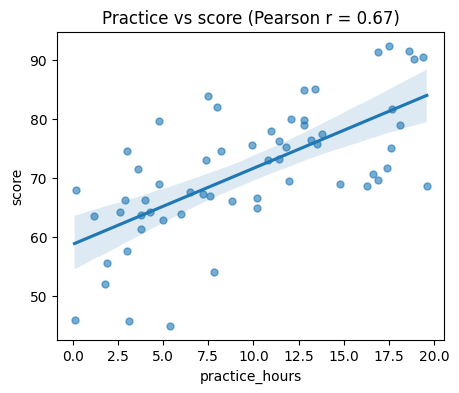

In [14]:
# Do practice hours relate to score?
r_pearson, p_pearson = stats.pearsonr(df["practice_hours"], df["score"])
r_spearman, p_spearman = stats.spearmanr(df["practice_hours"], df["score"])
print(f"Pearson  r = {r_pearson:.2f}, p = {p_pearson:.4f}  (linear)")
print(f"Spearman r = {r_spearman:.2f}, p = {p_spearman:.4f}  (monotonic, robust)")

# Always plot the relationship you are correlating.
fig, ax = plt.subplots(figsize=(5, 4))
sns.regplot(data=df, x="practice_hours", y="score", ax=ax,
            scatter_kws={"alpha": 0.6, "s": 25})
ax.set_title(f"Practice vs score (Pearson r = {r_pearson:.2f})")
plt.show()


<a id="s62"></a>
### 6.2. Simple Linear Regression — *"how much does Y change per unit of X?"*

**When to use it:** like correlation, but you want a **predictive equation**, `score = intercept + slope * practice_hours`. Regression gives you the *slope* (the change in Y for a one-unit rise in X), a significance test for it, and **R²** (the fraction of variance explained). We use `statsmodels`, whose summary table is the standard in research reporting — and the same engine behind the mixed-effects models next notebook.


In [15]:
# Fit score ~ practice_hours with ordinary least squares (OLS).
model = smf.ols("score ~ practice_hours", data=df).fit()
print(model.summary().tables[1])      # the coefficients table

slope = model.params["practice_hours"]
r2 = model.rsquared
print(f"\nInterpretation: each extra hour of practice predicts "
      f"{slope:+.2f} points of score.")
print(f"R-squared = {r2:.2f}  ->  practice explains {r2:.0%} of the variance in score.")


                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         58.7576      2.096     28.033      0.000      54.562      62.953
practice_hours     1.2863      0.186      6.908      0.000       0.914       1.659

Interpretation: each extra hour of practice predicts +1.29 points of score.
R-squared = 0.45  ->  practice explains 45% of the variance in score.


<a id="s63"></a>
### 6.3. Chi-Square Test — *"are two categorical variables associated?"*

**When to use it:** **both variables are categories** (group membership, pass/fail, behaviour type). It compares the counts you *observed* against the counts you'd *expect* if the two variables were unrelated. H0: the variables are independent.


In [16]:
# Are 'group' and 'passed' associated? Start with a contingency table of counts.
contingency = pd.crosstab(df["group"], df["passed"])
print("Observed counts:")
print(contingency, "\n")

chi2, p, dof, expected = stats.chi2_contingency(contingency)
print(f"Chi-square = {chi2:.2f}, dof = {dof}, p = {p:.4f}")
print("->", "group and outcome ARE associated" if p < 0.05
      else "no evidence of association")


Observed counts:
passed  fail  pass
group             
expert    12    18
novice    26     4 

Chi-square = 12.13, dof = 1, p = 0.0005
-> group and outcome ARE associated


> **Mini Challenge 6.** Build a contingency table of `method` × `passed` and run a chi-square test. Are some training methods linked to higher pass rates? (Watch the small cell counts — chi-square gets unreliable when expected counts drop below ~5.)

<a id="sec7"></a>
## Section 7: Choosing the Right Test & the Multiple-Comparisons Trap

### A decision guide

Work down these questions:

| Your question | Outcome type | Situation | Test |
| :--- | :--- | :--- | :--- |
| Mean vs a fixed value | numeric | one group | **one-sample t** (or Wilcoxon) |
| Two groups differ? | numeric | independent | **independent t / Welch** (or Mann–Whitney) |
| Same subjects changed? | numeric | paired | **paired t** (or Wilcoxon signed-rank) |
| 3+ groups differ? | numeric | independent | **one-way ANOVA + Tukey** (or Kruskal–Wallis) |
| Two variables move together? | numeric | — | **Pearson / Spearman correlation** |
| Predict Y from X? | numeric | — | **linear regression** |
| Two categories associated? | categorical | — | **chi-square** |

The non-parametric option in brackets is your fallback when normality fails or the data is ordinal.

### The multiple-comparisons trap

Every test at alpha = 0.05 has a 5% false-positive rate. Run **20 tests** on noise and, on average, **one will look "significant"** by chance. So:
* Decide your key comparisons *in advance*; do not fish through every pair.
* When you must run many tests, **correct for it** — Tukey's HSD (Section 4.4) does this for you, and methods like **Bonferroni** (divide alpha by the number of tests) do it generally.


In [17]:
# The trap, demonstrated. Imagine many studies, each running 20 t-tests on PURE
# NOISE (no real effects). How many "significant" hits show up per study?
per_study_hits = []
for study in range(1000):
    hits = sum(stats.ttest_ind(rng.normal(0, 1, 30), rng.normal(0, 1, 30))[1] < 0.05
               for _ in range(20))
    per_study_hits.append(hits)

print(f"Average false positives per 20-test study: {np.mean(per_study_hits):.2f}")
print(f"Studies with at least one false 'hit'    : {np.mean(np.array(per_study_hits) > 0):.0%}")
print("So with 20 tests you should EXPECT ~1 significant result even when nothing is real.")
print("Bonferroni fix: with 20 tests, use alpha = 0.05/20 =", round(0.05 / 20, 4))


Average false positives per 20-test study: 0.98
Studies with at least one false 'hit'    : 62%
So with 20 tests you should EXPECT ~1 significant result even when nothing is real.
Bonferroni fix: with 20 tests, use alpha = 0.05/20 = 0.0025


<a id="sec8"></a>
## Section 8: Bridge to Mixed-Effects Models + Weekly Challenge

Every test in this notebook rests on **independence** — each observation standing on its own. But behavioural data often violates this in a specific way: you measure the **same subject many times** (many frames per athlete, many trials per participant, many recordings per animal). Those repeated measurements are *correlated* — an athlete who is fast on trial 1 tends to be fast on trial 2 — and a plain t-test or ANOVA treats them as if they were independent, badly overstating your evidence.

The fix is a model that explicitly accounts for the structure: a **linear mixed-effects model**, which adds a "random effect" for each subject. That is exactly where the next notebook, *Intro to Mixed-Effects Models*, begins — with the question "why is a simple t-test not enough?" You now have the full answer: because the t-test assumes independence that repeated-measures data does not have.

> **Weekly Challenge.** Take a research question of your own (or reuse `df`) and run a complete mini-analysis:
> 1. State your H0 and H1 in one sentence each.
> 2. **Pick** the right test using the Section 7 guide, and justify the choice.
> 3. **Check** the relevant assumptions (Section 3).
> 4. **Run** the test and report the result *properly*: the statistic, the p-value, **an effect size**, and a 95% CI or group means.
> 5. Write a one-sentence plain-language conclusion — and one sentence on what the test does **not** prove.
>
> Doing all five, every time, is what turns "running statistics" into "doing statistics".

---

*End of Notebook. Next in this module: **Intro to Linear Mixed-Effects Models**, for when your data has repeated measures or nesting that these classical tests cannot handle.*
